# Domain Shift & Data Integration: Handling Non-IID Tabular Data

## Overview

In the previous notebooks, we established strong baselines and evaluated deep learning models under the assumption that our training and testing data are **IID** (Independent and Identically Distributed). However, in real-world scenarios—especially in high-dimensional biological and clinical data—this assumption frequently breaks down. 

Differences in laboratory equipment, batch processing, or environmental conditions create a phenomenon known as **Domain Shift** (or Batch Effects). The distribution of the data changes between the source (where we trained) and the target (where we deploy).

In this notebook, we will simulate the exact same level of technical noise (shift) on two distinct datasets:
* **Standard Tabular Data:** A classic dataset typical of finance or standard clinical records ($N=1000, P=20$).
* **Biological Data ($P \gg N$):** A high-dimensional dataset characterized by having significantly more features than samples ($N=500, P=2000$).

We will visually and quantitatively demonstrate how the "Curse of Dimensionality" makes high-dimensional data catastrophically vulnerable to these shifts, and explore how unsupervised **Domain Adaptation** techniques can rescue our models.

## Data Generation & Injecting the Shift

We begin by generating our synthetic datasets. To ensure a completely fair comparison, we will inject the exact same magnitude of "technical noise" (Domain Shift) into both the standard and the biological target datasets.

**The Process:**
1. **Source Domain:** Generated normally (e.g., representing "Lab A").
2. **Target Domain:** Generated from the same underlying distribution, but we add a constant random noise vector across all features (representing "Lab B" or a different batch).

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.linalg
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')

# Set seed for reproducibility
np.random.seed(42)

def generate_shifted_data(n_samples, n_features, shift_strength):
    """Generates Source and Target datasets with a constant technical shift."""
    # Generate Source data
    X_source,y_source = make_classification(
        n_samples=n_samples, n_features=n_features,
        n_informative=max(2,int(n_features * 0.1)), n_redundant=0, random_state=42
    )

    # Generate Target data (same biological distribution, different samples)
    X_target, y_target = make_classification(
        n_samples=n_samples, n_features=n_features,
        n_informative=max(2,int(n_features * 0.1)), n_redundant=0, random_state=100
    )

    # Inject Domain Shift
    shift_vector = np.random.normal(loc=shift_strength, scale=0.1, size=n_features)
    X_target_shifted = X_target + shift_vector

    return X_source, y_source, X_target_shifted, y_target


# Generate Data
X_src_std, y_src_std, X_tgt_std, y_tgt_std = generate_shifted_data(1000, 20, 0.3)
X_src_bio, y_src_bio, X_tgt_bio, y_tgt_bio = generate_shifted_data(500, 2000,1.5)

print(f"Standard Data - Source: {X_src_std.shape}, Target: {X_tgt_std.shape}")
print(f"Biological Data - Source: {X_src_bio.shape}, Target: {X_tgt_bio.shape}")

Standard Data - Source: (1000, 20), Target: (1000, 20)
Biological Data - Source: (500, 2000), Target: (500, 2000)


## Visualizing the Domain Gap (PCA)

Before training any models, it is crucial to visually inspect the data. Because we cannot visualize 20 or 2,000 dimensions, we use **PCA (Principal Component Analysis)** to project the data down to 2 dimensions. 

PCA naturally captures the axes of maximum variance. If the Domain Shift (the technical noise) creates more variance than the underlying biological signal, PCA will clearly separate the domains.

* **Expectation for Standard Data:** The Source and Target distributions should still overlap significantly.
* **Expectation for Biological Data:** The accumulated noise across 2,000 dimensions should create a massive spatial gap, resulting in isolated "islands".

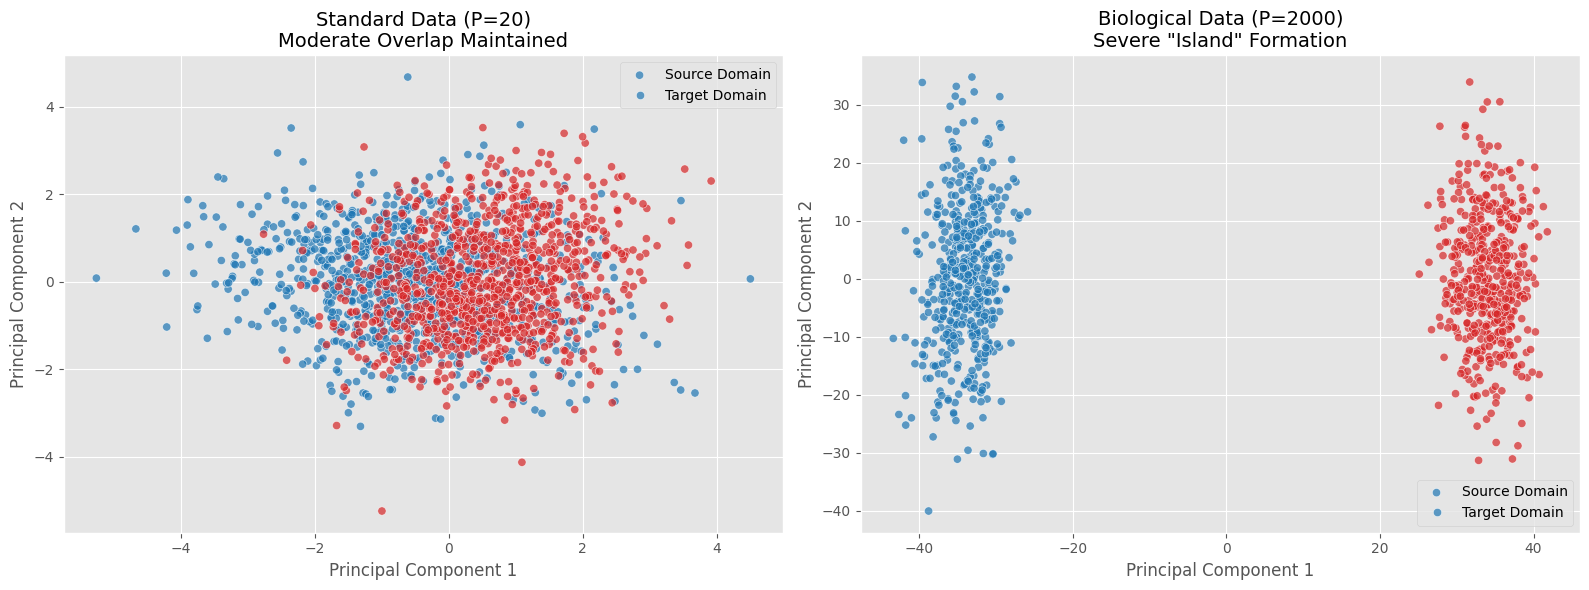

In [5]:
def plot_pca_domain_shift(X_src, X_tgt, title, ax):
    pca = PCA(n_components=2)
    X_combined = np.vstack((X_src, X_tgt))
    domains = np.array([0]*X_src.shape[0] + [1]*X_tgt.shape[0])
    
    X_pca = pca.fit_transform(X_combined)
    
    sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=domains, palette=['#1f77b4', '#d62728'], alpha=0.7, ax=ax)
    ax.set_title(title, fontsize=14)
    ax.set_xlabel('Principal Component 1')
    ax.set_ylabel('Principal Component 2')
    ax.legend(['Source Domain', 'Target Domain'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plot_pca_domain_shift(X_src_std, X_tgt_std, 'Standard Data (P=20)\nModerate Overlap Maintained', axes[0])
plot_pca_domain_shift(X_src_bio, X_tgt_bio, 'Biological Data (P=2000)\nSevere "Island" Formation', axes[1])
plt.tight_layout()
plt.show()